# 08 — Claim Occurrence Final Evaluation

## Projet : AI Business Advisor V2

### Objectif

Cette étape réalise l'évaluation finale du modèle Claim Occurrence
sur le jeu de test qui a été conservé totalement indépendant
durant le développement.

Toutes les décisions ont été prises avant l'ouverture du test :

- famille du modèle ;
- hyperparamètres ;
- méthode de calibration ;
- seuil de classification ;
- features ;
- preprocessing.

Configuration verrouillée :

- Modèle : XGBoost ;
- Calibration : Isotonic ;
- Seuil technique : 0.103271.

Le jeu de test final ne sera utilisé que pour mesurer les performances
de généralisation.

Aucun changement du modèle ne sera effectué sur la base
des résultats obtenus sur ce test.

In [9]:
import pandas as pd
import numpy as np

import json
import time
import joblib

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import StratifiedKFold

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from xgboost import XGBClassifier


RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

In [10]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:

    if path.exists():

        PROCESSED_DIR = path
        break


if PROCESSED_DIR is None:

    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = (
    PROCESSED_DIR.parent
)

METADATA_DIR = (
    DATA_DIR
    / "metadata"
)

DATA_SCIENCE_DIR = (
    DATA_DIR.parent
)

ARTIFACTS_DIR = (
    DATA_SCIENCE_DIR
    / "artifacts"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR = (
    DATA_SCIENCE_DIR
    / "reports"
    / "models"
    / "claim_occurrence"
    / "final"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Processed :",
    PROCESSED_DIR.resolve()
)

print(
    "Metadata :",
    METADATA_DIR.resolve()
)

print(
    "Artifacts :",
    ARTIFACTS_DIR.resolve()
)

print(
    "Reports :",
    REPORT_DIR.resolve()
)

Processed : C:\Users\user\ai-business-advisor-v2\data-science\data\processed
Metadata : C:\Users\user\ai-business-advisor-v2\data-science\data\metadata
Artifacts : C:\Users\user\ai-business-advisor-v2\data-science\artifacts
Reports : C:\Users\user\ai-business-advisor-v2\data-science\reports\models\claim_occurrence\final


In [11]:
split_df = pd.read_csv(
    METADATA_DIR
    / "freMTPL2_split.csv"
)

split_df[
    "split"
].value_counts()

split
development    541431
test           135358
Name: count, dtype: int64

In [12]:
with open(
    METADATA_DIR
    / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:

    feature_manifest = json.load(f)


config = (
    feature_manifest[
        "claim_occurrence"
    ]
)

config

{'target': 'has_claim',
 'numeric_features': ['Exposure',
  'VehPower',
  'VehAge',
  'DrivAge',
  'BonusMalus',
  'log_density'],
 'categorical_features': ['Area', 'VehBrand', 'VehGas', 'Region'],
 'excluded_features': ['IDpol', 'ClaimNb']}

In [13]:
with open(
    METADATA_DIR
    / "claim_occurrence_candidate.json",
    "r",
    encoding="utf-8"
) as f:

    candidate_config = json.load(f)


candidate_config

{'task': 'claim_occurrence',
 'model': 'xgboost',
 'best_cv_pr_auc': 0.14359548747868847,
 'best_parameters': {'model__subsample': 0.9,
  'model__scale_pos_weight': 5.0,
  'model__reg_lambda': 5.0,
  'model__reg_alpha': 0.01,
  'model__n_estimators': 200,
  'model__min_child_weight': 1,
  'model__max_depth': 6,
  'model__learning_rate': 0.05,
  'model__colsample_bytree': 0.7},
 'calibration': 'xgb_isotonic',
 'technical_threshold': 0.10327080885569255,
 'threshold_policy': 'maximum_f1_on_internal_calibration_set',
 'test_used': False}

In [14]:
print(
    "Model :",
    candidate_config["model"]
)

print(
    "Calibration :",
    candidate_config["calibration"]
)

print(
    "Threshold :",
    candidate_config["technical_threshold"]
)

print(
    "Test déjà utilisé ?",
    candidate_config["test_used"]
)

Model : xgboost
Calibration : xgb_isotonic
Threshold : 0.10327080885569255
Test déjà utilisé ? False


In [16]:
# ============================================================
# RECHARGEMENT OCCURRENCE + SPLIT + MERGE
# ============================================================

import pandas as pd
from pathlib import Path


# 1. Localiser data/processed
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:
    if path.exists():
        PROCESSED_DIR = path
        break

if PROCESSED_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = PROCESSED_DIR.parent
METADATA_DIR = DATA_DIR / "metadata"


print("PROCESSED_DIR :", PROCESSED_DIR.resolve())
print("METADATA_DIR  :", METADATA_DIR.resolve())


# ============================================================
# 2. Charger occurrence
# ============================================================

OCCURRENCE_PATH = (
    PROCESSED_DIR
    / "claim_occurrence_modeling_base.csv"
)

if not OCCURRENCE_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {OCCURRENCE_PATH}"
    )

occurrence = pd.read_csv(
    OCCURRENCE_PATH
)

print(
    "\nOccurrence chargée :",
    occurrence.shape
)

print(
    "Premières colonnes :",
    occurrence.columns.tolist()
)


# ============================================================
# 3. Charger le split
# ============================================================

SPLIT_PATH = (
    METADATA_DIR
    / "freMTPL2_split.csv"
)

if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {SPLIT_PATH}"
    )

split_df = pd.read_csv(
    SPLIT_PATH
)

print(
    "\nSplit chargé :",
    split_df.shape
)

print(
    split_df["split"]
    .value_counts(dropna=False)
)


# ============================================================
# 4. Vérifications des colonnes
# ============================================================

assert "IDpol" in occurrence.columns, (
    "IDpol absent de occurrence"
)

assert "IDpol" in split_df.columns, (
    "IDpol absent de split_df"
)

assert "split" in split_df.columns, (
    "La colonne split est absente de split_df"
)


# ============================================================
# 5. Harmoniser le type IDpol
# ============================================================

occurrence["IDpol"] = (
    occurrence["IDpol"]
    .astype("int64")
)

split_df["IDpol"] = (
    split_df["IDpol"]
    .astype("int64")
)


# ============================================================
# 6. Vérifier unicité
# ============================================================

assert occurrence["IDpol"].is_unique, (
    "IDpol n'est pas unique dans occurrence"
)

assert split_df["IDpol"].is_unique, (
    "IDpol n'est pas unique dans split_df"
)


# ============================================================
# 7. Vérifier si split existe déjà dans occurrence
# ============================================================

if "split" in occurrence.columns:
    occurrence = occurrence.drop(
        columns=["split"]
    )


# ============================================================
# 8. Faire le merge
# ============================================================

occurrence = occurrence.merge(
    split_df[["IDpol", "split"]],
    on="IDpol",
    how="left",
    validate="one_to_one"
)


# ============================================================
# 9. Vérification finale
# ============================================================

print(
    "\nOccurrence après merge :",
    occurrence.shape
)

print(
    "\nDistribution du split :"
)

print(
    occurrence["split"]
    .value_counts(dropna=False)
)


missing_split = (
    occurrence["split"]
    .isna()
    .sum()
)

print(
    "\nNombre de lignes sans split :",
    missing_split
)

assert missing_split == 0, (
    "Certaines observations n'ont pas de split"
)


print(
    "\n✅ occurrence existe maintenant"
)

print(
    "✅ split_df existe"
)

print(
    "✅ merge réalisé correctement"
)

PROCESSED_DIR : C:\Users\user\ai-business-advisor-v2\data-science\data\processed
METADATA_DIR  : C:\Users\user\ai-business-advisor-v2\data-science\data\metadata

Occurrence chargée : (676789, 12)
Premières colonnes : ['IDpol', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'log_density', 'Area', 'VehBrand', 'VehGas', 'Region', 'has_claim']

Split chargé : (676789, 2)
split
development    541431
test           135358
Name: count, dtype: int64

Occurrence après merge : (676789, 13)

Distribution du split :
split
development    541431
test           135358
Name: count, dtype: int64

Nombre de lignes sans split : 0

✅ occurrence existe maintenant
✅ split_df existe
✅ merge réalisé correctement


In [17]:
development = (
    occurrence[
        occurrence["split"] == "development"
    ]
    .copy()
)

test = (
    occurrence[
        occurrence["split"] == "test"
    ]
    .copy()
)

print(
    "Development :",
    development.shape
)

print(
    "Test :",
    test.shape
)

Development : (541431, 13)
Test : (135358, 13)


In [18]:
assert set(
    development["IDpol"]
).isdisjoint(
    set(
        test["IDpol"]
    )
)

print(
    "Aucun chevauchement DEV / TEST : OK"
)

Aucun chevauchement DEV / TEST : OK


In [19]:
print(
    "Development positive rate :",
    development[
        "has_claim"
    ].mean()
)

print(
    "Test positive rate :",
    test[
        "has_claim"
    ].mean()
)

Development positive rate : 0.05025017038182151
Test positive rate : 0.0502519245260716


In [20]:
numeric_features = (
    config[
        "numeric_features"
    ]
)

categorical_features = (
    config[
        "categorical_features"
    ]
)

features = (
    numeric_features
    +
    categorical_features
)

target = (
    config[
        "target"
    ]
)

In [21]:
X_dev = (
    development[
        features
    ]
    .copy()
)

y_dev = (
    development[
        target
    ]
    .copy()
)

In [22]:
X_test = (
    test[
        features
    ]
    .copy()
)

y_test = (
    test[
        target
    ]
    .copy()
)

In [23]:
assert "ClaimNb" not in X_dev.columns
assert "ClaimNb" not in X_test.columns

assert "has_claim" not in X_dev.columns
assert "has_claim" not in X_test.columns

assert "IDpol" not in X_dev.columns
assert "IDpol" not in X_test.columns

print(
    "Leakage controls : OK"
)

Leakage controls : OK


In [24]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [25]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [27]:
best_parameters = (
    candidate_config[
        "best_parameters"
    ]
)

In [29]:
xgb_parameters = {
    key.replace(
        "model__",
        ""
    ):
    value

    for key, value
    in best_parameters.items()
}

xgb_parameters

{'subsample': 0.9,
 'scale_pos_weight': 5.0,
 'reg_lambda': 5.0,
 'reg_alpha': 0.01,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [30]:
final_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **xgb_parameters
)

In [31]:
final_base_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            final_xgb
        )
    ]
)

In [32]:
final_calibration_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [33]:
final_model = CalibratedClassifierCV(
    estimator=final_base_pipeline,
    method="isotonic",
    cv=final_calibration_cv
)

In [34]:
start = time.perf_counter()

final_model.fit(
    X_dev,
    y_dev
)

final_training_time = (
    time.perf_counter()
    - start
)


print(
    f"Temps d'entraînement final : "
    f"{final_training_time:.2f} secondes"
)

Temps d'entraînement final : 49.43 secondes


# Ouverture du Test Final

À partir de cette cellule, le jeu de test final est consulté
pour la première fois.

La configuration du modèle est désormais verrouillée.

Les résultats obtenus ci-dessous sont considérés comme
l'estimation finale de généralisation.

Aucun tuning ou changement de configuration ne sera réalisé
à partir de ces résultats.

In [35]:
test_proba = (
    final_model
    .predict_proba(
        X_test
    )[:, 1]
)

In [36]:
pd.Series(
    test_proba
).describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
)

count    135358.000000
mean          0.050362
std           0.045919
min           0.000000
1%            0.005904
5%            0.008507
25%           0.025184
50%           0.041406
75%           0.059858
95%           0.122998
99%           0.268465
max           0.723520
dtype: float64

In [37]:
assert (
    (test_proba >= 0)
    &
    (test_proba <= 1)
).all()

print(
    "Probabilités valides : OK"
)

Probabilités valides : OK


In [38]:
test_pr_auc = (
    average_precision_score(
        y_test,
        test_proba
    )
)

test_roc_auc = (
    roc_auc_score(
        y_test,
        test_proba
    )
)

test_brier = (
    brier_score_loss(
        y_test,
        test_proba
    )
)

test_log_loss = (
    log_loss(
        y_test,
        test_proba
    )
)

In [39]:
print(
    f"PR-AUC    : {test_pr_auc:.6f}"
)

print(
    f"ROC-AUC   : {test_roc_auc:.6f}"
)

print(
    f"Brier     : {test_brier:.6f}"
)

print(
    f"Log Loss  : {test_log_loss:.6f}"
)

PR-AUC    : 0.142379
ROC-AUC   : 0.710567
Brier     : 0.045621
Log Loss  : 0.183422


In [40]:
test_prevalence = (
    y_test.mean()
)

pr_auc_lift = (
    test_pr_auc
    /
    test_prevalence
)

In [41]:
print(
    f"Test prevalence : "
    f"{test_prevalence:.6f}"
)

print(
    f"PR-AUC : "
    f"{test_pr_auc:.6f}"
)

print(
    f"PR-AUC / prevalence : "
    f"{pr_auc_lift:.2f}x"
)

Test prevalence : 0.050252
PR-AUC : 0.142379
PR-AUC / prevalence : 2.83x


In [42]:
FINAL_THRESHOLD = float(
    candidate_config[
        "technical_threshold"
    ]
)

print(
    "Threshold verrouillé :",
    FINAL_THRESHOLD
)

Threshold verrouillé : 0.10327080885569255


In [43]:
test_pred = (
    test_proba
    >= FINAL_THRESHOLD
).astype(int)

In [44]:
test_precision = (
    precision_score(
        y_test,
        test_pred,
        zero_division=0
    )
)

test_recall = (
    recall_score(
        y_test,
        test_pred,
        zero_division=0
    )
)

test_f1 = (
    f1_score(
        y_test,
        test_pred,
        zero_division=0
    )
)

In [45]:
print(
    f"Precision : {test_precision:.6f}"
)

print(
    f"Recall    : {test_recall:.6f}"
)

print(
    f"F1        : {test_f1:.6f}"
)

Precision : 0.186266
Recall    : 0.238459
F1        : 0.209155


In [46]:
final_cm = confusion_matrix(
    y_test,
    test_pred
)

final_cm

array([[121470,   7086],
       [  5180,   1622]])

In [47]:
tn, fp, fn, tp = (
    final_cm.ravel()
)

print(
    "True Negative  :",
    tn
)

print(
    "False Positive :",
    fp
)

print(
    "False Negative :",
    fn
)

print(
    "True Positive  :",
    tp
)

True Negative  : 121470
False Positive : 7086
False Negative : 5180
True Positive  : 1622


In [48]:
print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9591    0.9449    0.9519    128556
           1     0.1863    0.2385    0.2092      6802

    accuracy                         0.9094    135358
   macro avg     0.5727    0.5917    0.5805    135358
weighted avg     0.9203    0.9094    0.9146    135358



In [49]:
precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_proba
    )
)

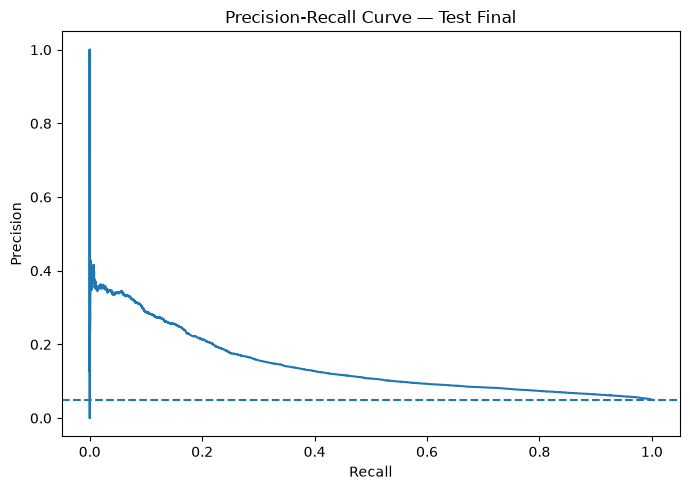

In [50]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    recall_curve,
    precision_curve
)

plt.axhline(
    y=test_prevalence,
    linestyle="--"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve — Test Final"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "final_precision_recall_curve.png",
    dpi=150
)

plt.show()

In [51]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_proba
)

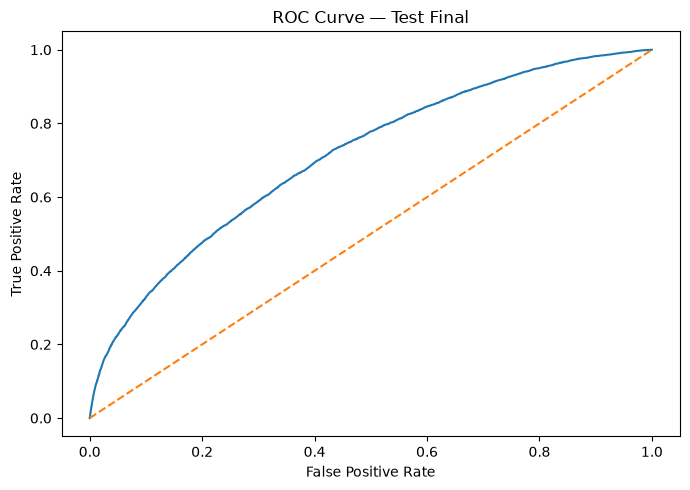

In [52]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Test Final"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "final_roc_curve.png",
    dpi=150
)

plt.show()

In [53]:
prob_true, prob_pred = (
    calibration_curve(
        y_test,
        test_proba,
        n_bins=10,
        strategy="quantile"
    )
)

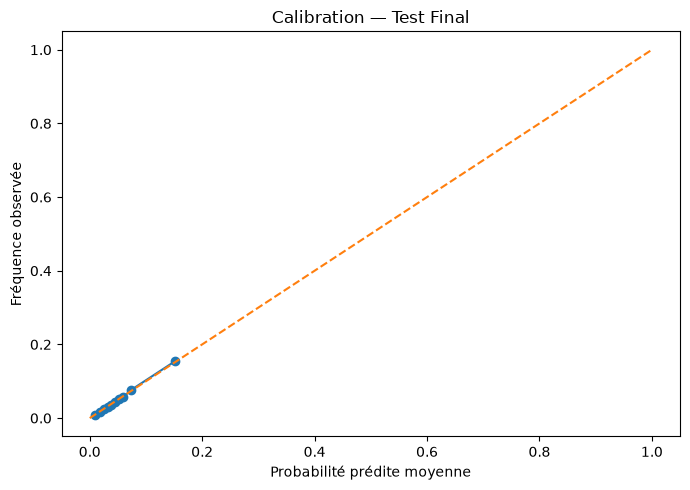

In [54]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Probabilité prédite moyenne"
)

plt.ylabel(
    "Fréquence observée"
)

plt.title(
    "Calibration — Test Final"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "final_calibration_curve.png",
    dpi=150
)

plt.show()

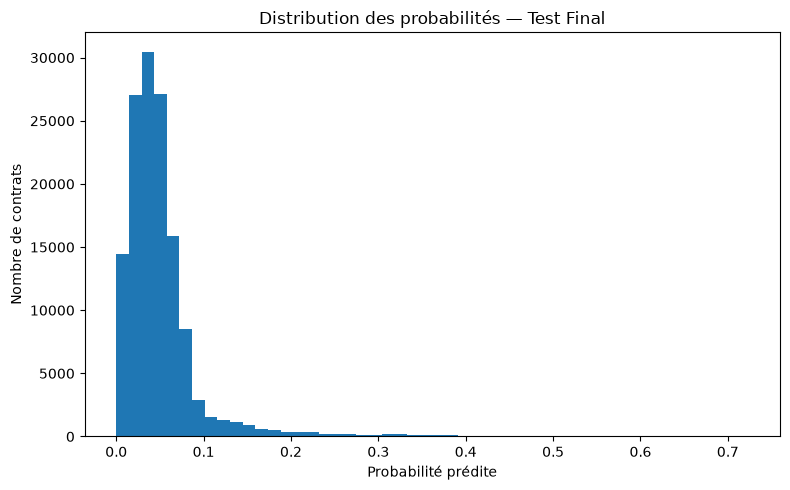

In [55]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    test_proba,
    bins=50
)

plt.xlabel(
    "Probabilité prédite"
)

plt.ylabel(
    "Nombre de contrats"
)

plt.title(
    "Distribution des probabilités — Test Final"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "final_probability_distribution.png",
    dpi=150
)

plt.show()

In [56]:
test_predictions_df = pd.DataFrame({
    "IDpol":
        test["IDpol"].values,

    "actual":
        y_test.values,

    "probability":
        test_proba,

    "prediction":
        test_pred
})

In [57]:
test_predictions_df[
    "risk_decile"
] = pd.qcut(
    test_predictions_df[
        "probability"
    ],
    q=10,
    labels=False,
    duplicates="drop"
)

In [59]:
decile_analysis = (
    test_predictions_df
    .groupby(
        "risk_decile"
    )
    .agg(
        n=(
            "IDpol",
            "size"
        ),

        mean_probability=(
            "probability",
            "mean"
        ),

        observed_claim_rate=(
            "actual",
            "mean"
        ),

        claims=(
            "actual",
            "sum"
        )
    )
)

decile_analysis

,n,mean_probability,observed_claim_rate,claims
risk_decile,,,,
0,13627,0.008852,0.009173,125
1,13464,0.018293,0.016860,227
2,13526,0.025244,0.025506,345
3,13540,0.032015,0.030355,411
4,13522,0.038513,0.036089,488
5,13537,0.044597,0.044692,605
6,13549,0.051382,0.052329,709
7,13523,0.059916,0.057310,775
8,13534,0.073055,0.075809,1026


In [60]:
highest_decile = (
    decile_analysis
    .iloc[-1]
)

portfolio_rate = (
    y_test.mean()
)

top_decile_lift = (
    highest_decile[
        "observed_claim_rate"
    ]
    /
    portfolio_rate
)

In [61]:
print(
    "Portfolio claim rate :",
    portfolio_rate
)

print(
    "Top decile claim rate :",
    highest_decile[
        "observed_claim_rate"
    ]
)

print(
    "Top decile lift :",
    top_decile_lift
)

Portfolio claim rate : 0.0502519245260716
Top decile claim rate : 0.15447695035460993
Top decile lift : 3.074050433122507


In [62]:
test_predictions_df.to_csv(
    REPORT_DIR
    / "final_test_predictions.csv",
    index=False
)

In [63]:
decile_analysis.to_csv(
    REPORT_DIR
    / "final_risk_decile_analysis.csv"
)

In [65]:
final_metrics = pd.DataFrame([
    {
        "model":
            "XGBoost + Isotonic",

        "test_prevalence":
            test_prevalence,

        "pr_auc":
            test_pr_auc,

        "roc_auc":
            test_roc_auc,

        "brier":
            test_brier,

        "log_loss":
            test_log_loss,

        "threshold":
            FINAL_THRESHOLD,

        "precision":
            test_precision,

        "recall":
            test_recall,

        "f1":
            test_f1,

        "tn":
            tn,

        "fp":
            fp,

        "fn":
            fn,

        "tp":
            tp,

        "pr_auc_lift_vs_prevalence":
            pr_auc_lift,

        "top_decile_lift":
            top_decile_lift,

        "training_time_seconds":
            final_training_time
    }
])

final_metrics.T

,0
model,XGBoost + Isotonic
test_prevalence,0.050252
pr_auc,0.142379
roc_auc,0.710567
brier,0.045621
log_loss,0.183422
threshold,0.103271
precision,0.186266
recall,0.238459
f1,0.209155


In [66]:
final_metrics.to_csv(
    REPORT_DIR
    / "final_test_metrics.csv",
    index=False
)

In [67]:
validation_reference = {
    "pr_auc": 0.144047,
    "roc_auc": 0.700993,
    "brier": 0.045624,
    "precision": 0.180027,
    "recall": 0.248484,
    "f1": 0.208787
}

In [68]:
generalization_comparison = pd.DataFrame([
    {
        "metric": "PR-AUC",
        "validation": validation_reference["pr_auc"],
        "test": test_pr_auc
    },
    {
        "metric": "ROC-AUC",
        "validation": validation_reference["roc_auc"],
        "test": test_roc_auc
    },
    {
        "metric": "Brier",
        "validation": validation_reference["brier"],
        "test": test_brier
    },
    {
        "metric": "Precision",
        "validation": validation_reference["precision"],
        "test": test_precision
    },
    {
        "metric": "Recall",
        "validation": validation_reference["recall"],
        "test": test_recall
    },
    {
        "metric": "F1",
        "validation": validation_reference["f1"],
        "test": test_f1
    }
])

generalization_comparison

,metric,validation,test
0,PR-AUC,0.144047,0.142379
1,ROC-AUC,0.700993,0.710567
2,Brier,0.045624,0.045621
3,Precision,0.180027,0.186266
4,Recall,0.248484,0.238459
5,F1,0.208787,0.209155


In [69]:
generalization_comparison.to_csv(
    REPORT_DIR
    / "validation_vs_test.csv",
    index=False
)

In [70]:
MODEL_PATH = (
    ARTIFACTS_DIR
    / "claim_occurrence_xgb_isotonic.joblib"
)

In [71]:
joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Modèle sauvegardé :",
    MODEL_PATH
)

Modèle sauvegardé : c:\Users\user\ai-business-advisor-v2\data-science\artifacts\claim_occurrence_xgb_isotonic.joblib


In [72]:
loaded_model = joblib.load(
    MODEL_PATH
)

In [73]:
sample_X = (
    X_test
    .head(5)
    .copy()
)

In [74]:
original_predictions = (
    final_model
    .predict_proba(
        sample_X
    )[:, 1]
)

In [75]:
reloaded_predictions = (
    loaded_model
    .predict_proba(
        sample_X
    )[:, 1]
)

In [76]:
np.testing.assert_allclose(
    original_predictions,
    reloaded_predictions
)

print(
    "Reload test : OK"
)

Reload test : OK


In [77]:
final_model_metadata = {

    "model_name":
        "claim_occurrence_xgboost",

    "model_type":
        "XGBClassifier",

    "calibration":
        "isotonic",

    "model_version":
        "1.0.0",

    "target":
        "has_claim",

    "features":
        features,

    "technical_threshold":
        FINAL_THRESHOLD,

    "hyperparameters":
        xgb_parameters,

    "final_test_metrics":
        final_metrics
        .iloc[0]
        .to_dict(),

    "test_policy":
        "used once after model configuration lock",

    "artifact":
        MODEL_PATH.name
}

In [78]:
def convert_to_python_type(
    value
):

    if isinstance(
        value,
        np.generic
    ):

        return value.item()

    return value

In [79]:
final_model_metadata[
    "final_test_metrics"
] = {
    key:
        convert_to_python_type(
            value
        )

    for key, value
    in final_model_metadata[
        "final_test_metrics"
    ].items()
}

In [80]:
with open(
    METADATA_DIR
    / "claim_occurrence_model_v1.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_model_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

In [81]:
candidate_config[
    "test_used"
] = True

In [82]:
candidate_config[
    "test_evaluation_completed"
] = True

In [83]:
with open(
    METADATA_DIR
    / "claim_occurrence_candidate.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        candidate_config,
        f,
        indent=4,
        ensure_ascii=False
    )

In [84]:
print(
    "=" * 80
)

print(
    "CLAIM OCCURRENCE — FINAL TEST RESULTS"
)

print(
    "=" * 80
)


print(
    "\n=== DATA ==="
)

print(
    "Development size :",
    len(development)
)

print(
    "Test size :",
    len(test)
)

print(
    "Test positive rate :",
    f"{test_prevalence:.6f}"
)


print(
    "\n=== FINAL MODEL ==="
)

print(
    "Model : XGBoost"
)

print(
    "Calibration : Isotonic"
)

print(
    "Threshold :",
    FINAL_THRESHOLD
)

print(
    "Hyperparameters :"
)

for key, value in (
    xgb_parameters.items()
):

    print(
        f"{key} = {value}"
    )


print(
    "\n=== PROBABILITY METRICS ==="
)

print(
    f"PR-AUC   : {test_pr_auc:.6f}"
)

print(
    f"ROC-AUC  : {test_roc_auc:.6f}"
)

print(
    f"Brier    : {test_brier:.6f}"
)

print(
    f"Log Loss : {test_log_loss:.6f}"
)

print(
    f"PR-AUC lift vs prevalence : "
    f"{pr_auc_lift:.3f}x"
)


print(
    "\n=== THRESHOLD METRICS ==="
)

print(
    f"Precision : {test_precision:.6f}"
)

print(
    f"Recall    : {test_recall:.6f}"
)

print(
    f"F1        : {test_f1:.6f}"
)


print(
    "\n=== CONFUSION MATRIX ==="
)

print(
    final_cm
)

print(
    f"TN = {tn}"
)

print(
    f"FP = {fp}"
)

print(
    f"FN = {fn}"
)

print(
    f"TP = {tp}"
)


print(
    "\n=== RISK SEGMENTATION ==="
)

print(
    f"Portfolio claim rate : "
    f"{portfolio_rate:.6f}"
)

print(
    f"Top decile claim rate : "
    f"{highest_decile['observed_claim_rate']:.6f}"
)

print(
    f"Top decile lift : "
    f"{top_decile_lift:.3f}x"
)


print(
    "\n=== VALIDATION VS TEST ==="
)

print(
    generalization_comparison
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== ARTIFACT ==="
)

print(
    MODEL_PATH
)

print(
    "Reload test : OK"
)


print(
    "\nTEST FINAL UTILISÉ : OUI"
)

print(
    "CONFIGURATION MODIFIABLE APRÈS TEST : NON"
)


print(
    "=" * 80
)

CLAIM OCCURRENCE — FINAL TEST RESULTS

=== DATA ===
Development size : 541431
Test size : 135358
Test positive rate : 0.050252

=== FINAL MODEL ===
Model : XGBoost
Calibration : Isotonic
Threshold : 0.10327080885569255
Hyperparameters :
subsample = 0.9
scale_pos_weight = 5.0
reg_lambda = 5.0
reg_alpha = 0.01
n_estimators = 200
min_child_weight = 1
max_depth = 6
learning_rate = 0.05
colsample_bytree = 0.7

=== PROBABILITY METRICS ===
PR-AUC   : 0.142379
ROC-AUC  : 0.710567
Brier    : 0.045621
Log Loss : 0.183422
PR-AUC lift vs prevalence : 2.833x

=== THRESHOLD METRICS ===
Precision : 0.186266
Recall    : 0.238459
F1        : 0.209155

=== CONFUSION MATRIX ===
[[121470   7086]
 [  5180   1622]]
TN = 121470
FP = 7086
FN = 5180
TP = 1622

=== RISK SEGMENTATION ===
Portfolio claim rate : 0.050252
Top decile claim rate : 0.154477
Top decile lift : 3.074x

=== VALIDATION VS TEST ===
   metric  validation     test
   PR-AUC    0.144047 0.142379
  ROC-AUC    0.700993 0.710567
    Brier    0.04

# Évaluation finale du modèle d'occurrence de sinistre

Après la phase de comparaison, de tuning et de calibration, le modèle retenu
pour la prédiction de l'occurrence d'un sinistre est un XGBoost calibré
par méthode isotonic.

La configuration du modèle a été entièrement verrouillée avant l'ouverture
du jeu de test final.

Le jeu de test contient 135 358 contrats, avec une prévalence de sinistre
de 5,0252 %.

## Performances finales

Le modèle obtient les performances suivantes :

| Métrique | Résultat |
|---|---:|
| PR-AUC | 0.142379 |
| ROC-AUC | 0.710567 |
| Brier Score | 0.045621 |
| Log Loss | 0.183422 |
| Precision | 0.186266 |
| Recall | 0.238459 |
| F1-score | 0.209155 |

La PR-AUC est environ 2,83 fois supérieure à la prévalence de la classe
positive, ce qui confirme que le modèle possède une capacité réelle
à hiérarchiser les contrats selon leur risque de sinistre.

Le ROC-AUC de 0,7106 indique une capacité de discrimination correcte.

Le Brier Score de 0,0456 est très proche de celui observé sur le jeu
de validation, ce qui montre que la calibration reste stable sur des
données jamais utilisées pendant le développement.

## Matrice de confusion

Au seuil technique de 0,103271, la matrice de confusion obtenue est :

| | Prédit sans sinistre | Prédit avec sinistre |
|---|---:|---:|
| Réel sans sinistre | 121 470 | 7 086 |
| Réel avec sinistre | 5 180 | 1 622 |

Le modèle détecte donc 1 622 contrats sinistrés sur 6 802.

Le Recall atteint 23,85 %, tandis que la Precision atteint 18,63 %.

Le seuil utilisé correspond à un seuil technique sélectionné sur le jeu
de validation afin de maximiser le F1-score. Il ne doit pas être interprété
comme un seuil métier optimal, car les coûts des faux positifs et faux
négatifs ne sont pas disponibles dans le dataset.

## Analyse par déciles de risque

Le taux moyen de sinistre du portefeuille est de 5,03 %.

Pour les 10 % de contrats possédant les scores de risque les plus élevés,
le taux observé atteint 15,45 %.

Le lift du premier décile de risque est donc de 3,074.

Cette analyse montre que le modèle parvient à concentrer une proportion
significativement plus élevée de sinistres dans les groupes auxquels
il attribue les scores les plus élevés.

## Généralisation

Les performances observées sur le jeu de test sont très proches de celles
obtenues sur le jeu de validation.

| Métrique | Validation | Test |
|---|---:|---:|
| PR-AUC | 0.144047 | 0.142379 |
| ROC-AUC | 0.700993 | 0.710567 |
| Brier | 0.045624 | 0.045621 |
| Precision | 0.180027 | 0.186266 |
| Recall | 0.248484 | 0.238459 |
| F1 | 0.208787 | 0.209155 |

Cette proximité indique que le modèle généralise de manière stable
sur le jeu de test indépendant.

Le modèle final est sauvegardé sous forme d'un artefact contenant
le preprocessing, le modèle XGBoost et la calibration isotonic.

Le test de rechargement de l'artefact a confirmé que les prédictions
restent identiques après sérialisation.